# Interim report: problem framing and data understanding

This notebook consolidates the report's data overview, distributions and feature dictionary. It follows the interim guideline; model training and architecture selection are not required at this stage.

| Report section | Notebook section |
|---|---|
| Part 1. Machine learning problem | 1 |
| 2.1 Data overview and sampling scheme | 3 |
| 2.2 Impression, exposure and interaction dynamics | 4 |
| 2.3 Feature dictionary and descriptive statistics | 5 |
| Limitations and risks | 6 |

**Scope:** raw-data summaries use all 173,831 records and the full catalog. Engineered-feature statistics use a uniform 5,000-record sample, seed 4222, preserving all candidates and all supplied history. The same sample is used in notebooks 03 and 04. No model-development sample size or architecture is committed here.

The raw files are streamed into compact summaries; a full 15.5-million-row feature table is not constructed. Generated tables and figures are saved under ignored `outputs/interim/`. Notebooks 03 and 04 retain the detailed diagnostic experiments and uncertainty estimates.


## 1. Business problem and ML task

**Business context.** JDSearch provides a current query, candidate products, and the shopper's supplied interaction history. Historical preferences may help the current search, but the relevance of those behaviours can vary with the query and candidate.

- **Business objective:** improve search relevance by using historical preferences where they provide useful evidence for the current query. Helping shoppers find suitable products and supporting purchases are the business motivations; offline ranking quality is the measurable outcome.
- **ML task:** personalised re-ranking of the supplied candidate products for each search.
- **Inputs:** the current query, supplied history (products, action types, historical queries, and relative time gaps), and candidate metadata (title tokens, brand, four category levels, and shop).
- **Input sample and grouping:** a (search, candidate) pair scored in the context of its complete search record. All candidates for one search form a ranking group and remain together when sampling or splitting.
- **Target:** the observed candidate interaction grades: 0 = no interaction, 1 = click, 2 = add to cart, 3 = purchase. These labels supervise candidate ranking; they do not measure monetary value or reveal the shopper's underlying intention directly.
- **Investigation:** which historical behaviours provide useful predictive evidence for the current search? Explore query relevance, product/brand/shop matches, category depth, action type, query presence, and recency. Category depth and adaptive history selection remain hypotheses to test.

**Evaluation direction.** Evaluate on full, un-downsampled candidate lists using graded ranking metrics such as NDCG@10, with MRR and Recall@k as supporting measures. Document relevance gains and treatment of all-zero lists before model comparisons. Offline results will not establish increased revenue, satisfaction, or reduced search effort.

**Model selection remains open.** Concrete architectures, training objectives, and feature combinations will be selected after exploration and baseline comparisons. Binary engagement prediction may be a baseline without replacing the graded re-ranking task. Model training and completed feature engineering are not required for the interim report.

**Why ranking metrics, not accuracy alone.** About 98% of candidate labels are zero (section 4.2), so predicting no interaction everywhere gives high accuracy without establishing useful ranking quality.


## 2. Setup

In [1]:
from pathlib import Path
import sys

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_ROOT = next((p.resolve() for p in [Path.cwd(), *Path.cwd().parents]
                  if (p / "scripts/interim_eda.py").is_file()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Open/clone the repository checkout containing scripts/interim_eda.py first.")
if IN_COLAB:
    drive.mount("/content/drive")
    DATA_DIR = Path("/content/drive/MyDrive/BT4222 Group Project/data")
else:
    DATA_DIR = REPO_ROOT / "data"
USER_BEHAVIOR_PATH = DATA_DIR / "user_behavior_data.txt"
PRODUCT_META_PATH = DATA_DIR / "product_meta_data.txt"
assert USER_BEHAVIOR_PATH.is_file() and PRODUCT_META_PATH.is_file()
PROCESSED_DIR = DATA_DIR / "processed"
REPORT_DIR = REPO_ROOT / "outputs/interim"
FIG_DIR, TABLE_DIR = REPORT_DIR / "figures", REPORT_DIR / "tables"
for path in [PROCESSED_DIR, FIG_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)
SEED, EDA_SAMPLE_SIZE = 4222, 5000
print(f"Data folder: {DATA_DIR}")
print(f"Report outputs: {REPORT_DIR}")


Data folder: C:\Users\liamk\ClaudeProjects\BT4222\BT4222-group17-jdsearch\data
Report outputs: C:\Users\liamk\ClaudeProjects\BT4222\BT4222-group17-jdsearch\outputs\interim


In [2]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

sys.path.insert(0, str(REPO_ROOT))
from scripts.interim_eda import build_full_profile, build_sample_features, numeric_stats
from scripts.query_diagnostics import validate_helpers
from scripts.history_match_diagnostics import validate_match_helpers
validate_helpers()
validate_match_helpers()
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MUTED = "#898781"
plt.rcParams.update({"figure.figsize": (9, 4), "figure.dpi": 110, "savefig.dpi": 180,
                    "savefig.bbox": "tight", "axes.spines.top": False, "axes.spines.right": False,
                    "axes.grid": True, "grid.color": "#e6e5e1", "axes.axisbelow": True,
                    "axes.titleweight": "bold", "axes.titlelocation": "left"})
pd.options.display.float_format = "{:,.4f}".format
pd.options.display.max_colwidth = 100

def save_fig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")

def save_table(frame, name, scope):
    result = frame.copy()
    result["scope"] = scope
    result.to_csv(TABLE_DIR / f"{name}.csv")
    return result

FULL_SCOPE = "full behaviour file / full catalog as applicable"
SAMPLE_SCOPE = f"{EDA_SAMPLE_SIZE:,} complete records; seed {SEED}"


### 2.1 Stream the raw files

The helper validates record/list alignment, labels, initial time placeholders and nonnegative gaps. It stores item IDs as compact numeric arrays for exact entity counts, avoiding full text tables and candidate-feature matrices. Temporary population-frequency arrays are saved under ignored `data/processed/` for descriptive use only.


In [3]:
full = build_full_profile(DATA_DIR)
record_summary = full["sessions"]
n_sessions = len(record_summary)
print(f"Records: {n_sessions:,}; candidates: {full['candidate_count']:,}; history actions: {full['history_count']:,}")
print("Raw list lengths, label values, time alignment and catalog ID uniqueness passed.")


Behaviour records summarised: 50,000
Behaviour records summarised: 100,000
Behaviour records summarised: 150,000
Catalog rows summarised: 4,000,000
Catalog rows summarised: 8,000,000
Catalog rows summarised: 12,000,000
Records: 173,831; candidates: 15,510,012; history actions: 26,667,260
Raw list lengths, label values, time alignment and catalog ID uniqueness passed.


In [4]:
display(save_table(full["metadata_coverage"], "2_1_metadata_coverage_full", FULL_SCOPE))
print(f"Catalog products: {full['catalog_count']:,}")


Catalog products: 12,141,247


,metadata present share,scope
Candidate occurrences,0.9955,full behaviour file / full catalog as applicable
Historical actions,0.9514,full behaviour file / full catalog as applicable


## 3. Data overview and sampling scheme (report 2.1)

### 3.1 Source and entity counts

- **Source:** Liu et al. (2023), *JDsearch: A Personalized Product Search Dataset with Real Queries and Full Interactions*, SIGIR. [Paper](https://arxiv.org/html/2305.14810); [format README](https://github.com/rucliujn/JDsearch#dataset-files).
- **Record unit:** the source describes one sampled user's last test query and supplied history per row. No persistent user-ID field is released, so rows provide the grouping; we cannot link additional searches to an account ourselves.
- **Anonymisation:** query and metadata text contain term IDs separated by `\x18`; list entries use `_`. Original words are unavailable, but token boundaries are recoverable.


In [30]:
overview = full["overview"].copy()
overview.loc["Distinct products across catalog and behaviour", "count"] = (
    int(overview.loc["Products in catalog", "count"]) +
    int(overview.loc["Behaviour products missing from catalog", "count"])
)
display(save_table(overview, "2_1_entity_counts", FULL_SCOPE))


,count,scope
Users / supplied search records,173831.0,full behaviour file / full catalog as applicable
Distinct current query strings,111556.0,full behaviour file / full catalog as applicable
Candidate occurrences,15510012.0,full behaviour file / full catalog as applicable
History actions,26667260.0,full behaviour file / full catalog as applicable
Products in catalog,12141247.0,full behaviour file / full catalog as applicable
Distinct candidate products,8362535.0,full behaviour file / full catalog as applicable
Distinct history products,5584543.0,full behaviour file / full catalog as applicable
Distinct products in any behaviour,12319978.0,full behaviour file / full catalog as applicable
Behaviour products missing from catalog,731389.0,full behaviour file / full catalog as applicable
Distinct brands,182585.0,full behaviour file / full catalog as applicable


### 3.2 Collection period and relative time

The paper's section 3.1 documents history collection from **18 October 2021 to 17 October 2022**, with last test queries on **17 October 2022**. The released file provides relative gaps, not absolute row timestamps; the documented collection period is reportable, but a cross-user chronological split cannot be reconstructed from those gaps.

The README specifies an initial zero, one gap for each transition, and a final gap to the test query. Length and initial-zero checks are validated on every record. Raw intervals are reported directly. Hours/days below **assume seconds**, following the course's examples; the released schema does not explicitly state the unit. Derived spans are not used to infer a new collection period.


In [6]:
span_days = record_summary.history_span_raw / 86400
span = span_days.describe(percentiles=[.25, .5, .75, .95]).rename("history span in days (seconds assumed)")
display(save_table(span.to_frame(), "2_1_history_span_days_assumed", FULL_SCOPE))
print(f"Derived spans over 365 days: {(span_days > 365).sum():,} ({(span_days > 365).mean():.4%})")
print("Spans exceeding the documented year need a time-unit/logging audit before calendar interpretation.")


Derived spans over 365 days: 1 (0.0006%)
Spans exceeding the documented year need a time-unit/logging audit before calendar interpretation.


,history span in days (seconds assumed),scope
count,"173,831.0000",full behaviour file / full catalog as applicable
mean,231.9745,full behaviour file / full catalog as applicable
std,128.1893,full behaviour file / full catalog as applicable
min,0.0000,full behaviour file / full catalog as applicable
25%,105.7432,full behaviour file / full catalog as applicable
50%,282.9926,full behaviour file / full catalog as applicable
75%,349.6473,full behaviour file / full catalog as applicable
95%,362.3559,full behaviour file / full catalog as applicable
max,635.2886,full behaviour file / full catalog as applicable


### 3.3 Sampling scheme

Raw summaries cover the full files. Engineered features use a **uniform sample of 5,000 whole search records**, with seed 4222; every candidate and historical action in each selected row is retained. Metadata is looked up against the complete catalog for both history and candidates, avoiding artificial missingness.

This is an exploratory feature sample, not a train/test split. Model-development size and grouped split proportions remain open. Later comparisons will keep whole search records together, retain complete evaluation slates, and isolate training-only population statistics. Compare headline distributions below; a random sample does not remove the source dataset's selection bias or guarantee adequate rare subgroups.


In [7]:
rng = np.random.default_rng(SEED)
sample_ids = np.sort(rng.choice(n_sessions, min(EDA_SAMPLE_SIZE, n_sessions), replace=False))
sample_path = PROCESSED_DIR / f"interim_eda_records_n{len(sample_ids)}_seed{SEED}.csv"
pd.DataFrame({"session_id": sample_ids}).to_csv(sample_path, index=False)
print(f"Saved {len(sample_ids):,} record indices; all candidates retained; no model split assigned.")


Saved 5,000 record indices; all candidates retained; no model split assigned.


In [8]:
def profile(rows):
    return {"records": len(rows), "candidate occurrences": rows.slate_len.sum(),
            "mean slate length": rows.slate_len.mean(), "median history length": rows.history_len.median(),
            "candidate engagement share": rows.positive_candidates.sum() / rows.slate_len.sum(),
            "candidate purchase-label share": rows.purchase_candidates.sum() / rows.slate_len.sum()}
representativeness = pd.DataFrame({"full file": profile(record_summary),
                                  "5,000-record sample": profile(record_summary.iloc[sample_ids])})
display(save_table(representativeness, "2_1_sample_vs_full", "full file compared with uniform feature sample"))


,full file,"5,000-record sample",scope
records,"173,831.0000","5,000.0000",full file compared with uniform feature sample
candidate occurrences,"15,510,012.0000","449,052.0000",full file compared with uniform feature sample
mean slate length,89.2247,89.8104,full file compared with uniform feature sample
median history length,78.0000,75.0000,full file compared with uniform feature sample
candidate engagement share,0.0207,0.0208,full file compared with uniform feature sample
candidate purchase-label share,0.0013,0.0013,full file compared with uniform feature sample


## 4. Impression, exposure and interaction dynamics (report 2.2)

### 4.1 Impression slates

,candidates per search,scope
count,"173,831.0000",full behaviour file / full catalog as applicable
mean,89.2247,full behaviour file / full catalog as applicable
std,38.8574,full behaviour file / full catalog as applicable
min,1.0000,full behaviour file / full catalog as applicable
5%,25.0000,full behaviour file / full catalog as applicable
25%,76.0000,full behaviour file / full catalog as applicable
50%,90.0000,full behaviour file / full catalog as applicable
75%,95.0000,full behaviour file / full catalog as applicable
95%,170.0000,full behaviour file / full catalog as applicable
max,200.0000,full behaviour file / full catalog as applicable


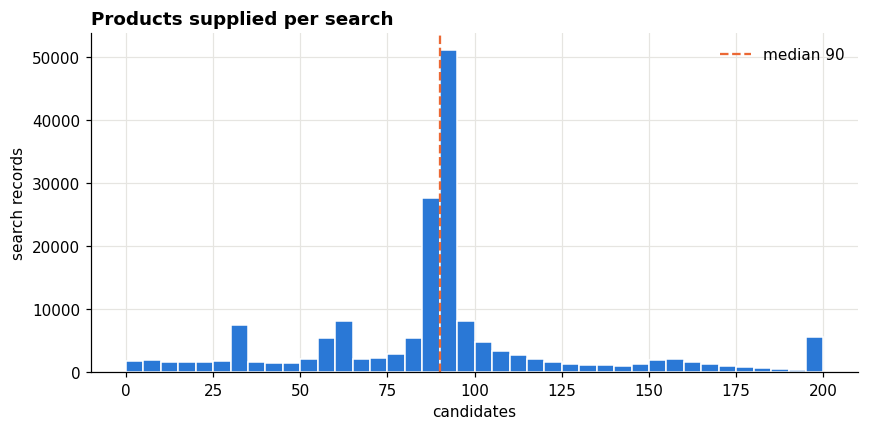

In [9]:
slate_len = record_summary.slate_len
slate_stats = slate_len.describe(percentiles=[.05, .25, .5, .75, .95]).rename("candidates per search")
display(save_table(slate_stats.to_frame(), "2_2_slate_length", FULL_SCOPE))
fig, ax = plt.subplots()
ax.hist(slate_len, bins=range(0, 205, 5), color=BLUE, edgecolor="white")
ax.axvline(slate_len.median(), color=ORANGE, linestyle="--", label=f"median {slate_len.median():.0f}")
ax.set(title="Products supplied per search", xlabel="candidates", ylabel="search records")
ax.legend(frameon=False)
save_fig(fig, "2_2_slate_length")


### 4.2 Interaction grades and thresholds

Each candidate has one label: 0 no recorded interaction, 1 click, 2 cart, 3 purchase. Show both exclusive label volumes and cumulative grade thresholds. These thresholds do **not** reveal the sequence of events: a purchase label does not establish an observed click-to-cart-to-purchase path. Ratios between threshold counts must not be called event conversion rates.


In [10]:
label_distribution = full["label_distribution"]
thresholds = full["thresholds"]
display(save_table(label_distribution, "2_2_interaction_labels", FULL_SCOPE))
display(save_table(thresholds, "2_2_interaction_thresholds", FULL_SCOPE))


,candidate occurrences,share of candidates,searches with this label,share of searches,scope
No recorded interaction (0),15189116,0.9793,173278,0.9968,full behaviour file / full catalog as applicable
Click label (1),224487,0.0145,126854,0.7298,full behaviour file / full catalog as applicable
Cart label (2),75573,0.0049,56775,0.3266,full behaviour file / full catalog as applicable
Purchase label (3),20836,0.0013,20306,0.1168,full behaviour file / full catalog as applicable


,candidate occurrences,share of candidates,searches with this threshold,share of searches,scope
All exposed candidates,15510012,1.0000,173831,1.0000,full behaviour file / full catalog as applicable
Any recorded engagement (>=1),320896,0.0207,171728,0.9879,full behaviour file / full catalog as applicable
Cart or purchase label (>=2),96409,0.0062,73438,0.4225,full behaviour file / full catalog as applicable
Purchase label (=3),20836,0.0013,20306,0.1168,full behaviour file / full catalog as applicable


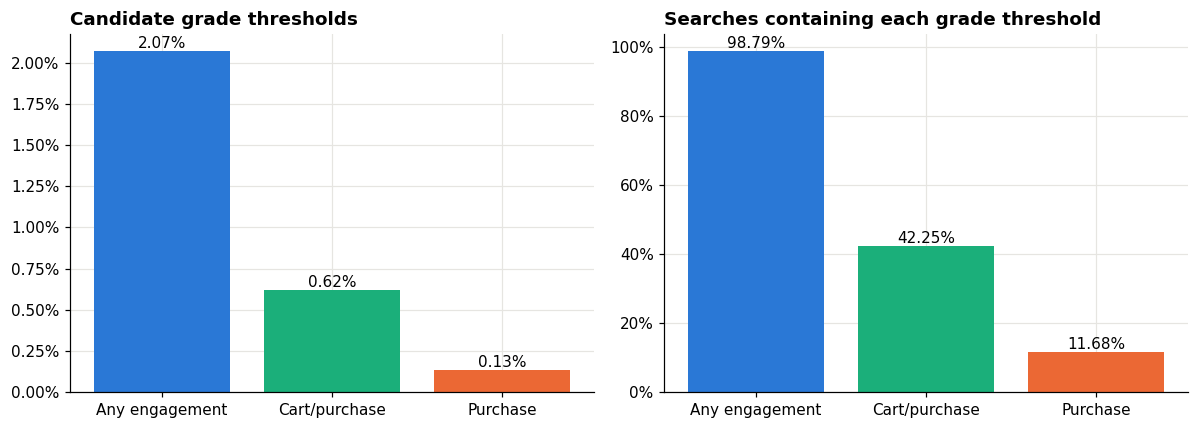

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, column, title in [(axes[0], "share of candidates", "Candidate grade thresholds"),
                          (axes[1], "share of searches", "Searches containing each grade threshold")]:
    values = thresholds[column].iloc[1:]
    ax.bar(["Any engagement", "Cart/purchase", "Purchase"], values, color=[BLUE, AQUA, ORANGE])
    for x, value in enumerate(values):
        ax.annotate(f"{value:.2%}", (x, value), ha="center", va="bottom")
    ax.set(title=title)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.tight_layout()
save_fig(fig, "2_2_interaction_thresholds")


**Interpretation.** Most candidates have no recorded interaction; accuracy alone would reward predicting zero. The supplied searches usually contain an engaged product, supporting evaluation of how it is ranked. This reflects the dataset's selected last-search records, not the probability that an arbitrary JD search converts. Purchase labels are observed outcomes, not measured revenue or evidence of the intervening interaction sequence.


### 4.3 Candidate-file order audit

The full-file check below verifies whether positive candidates are stored before negatives. This ordering cannot serve as a reliable recorded display rank, so a CTR-by-display-position analysis is unavailable. The chart describes a **file-order artifact**, not user position bias.

Future models will not receive candidate list indices as features. Shuffle candidates independently of labels or use random tie breaking at evaluation, preserving each candidate's label/metadata alignment. No training or ranking is performed in this notebook.


Positive-containing records with every positive before every negative: 100.00%
Records without positives: 2,103 (1.21%)


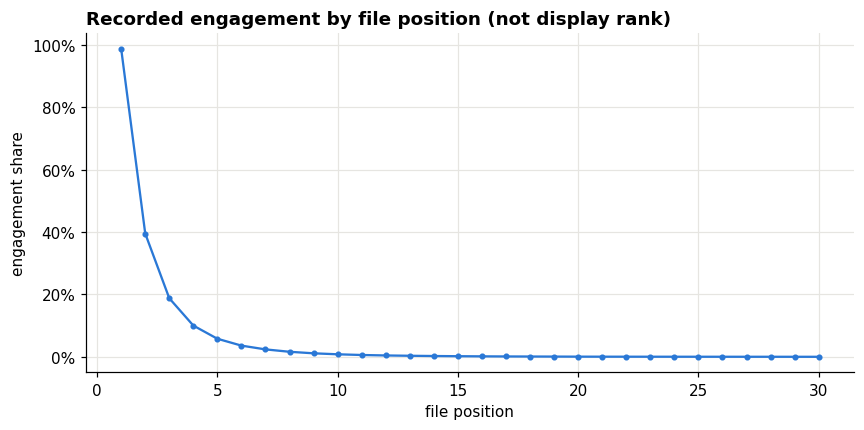

In [12]:
print(f"Positive-containing records with every positive before every negative: {full['positive_prefix_share']:.2%}")
print(f"Records without positives: {full['all_zero_records']:,} ({full['all_zero_records'] / n_sessions:.2%})")
assert full["positive_prefix_share"] == 1.0
fig, ax = plt.subplots()
ax.plot(full["position_rate"].index, full["position_rate"].values, color=BLUE, marker="o", markersize=3)
ax.set(title="Recorded engagement by file position (not display rank)", xlabel="file position", ylabel="engagement share")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
save_fig(fig, "2_2_position_artifact")


### 4.4 Feedback semantics

| Signal | Meaning |
|---|---|
| Candidate label 1–3 | Exposed with a recorded click/cart/purchase outcome |
| Candidate label 0 | Exposed without a recorded interaction; usable implicit negative, not an explicit dislike |
| Product outside this record's slate | Unobserved for this search; cannot infer exposure or preference |
| Historical action | A past recorded positive action; no historical exposure negatives are supplied |

A product absent from all supplied candidate lists may still have historical interactions. Neither absence from the current slate nor absence from every supplied slate proves it was never shown anywhere on JD. Planned supervised comparisons use the supplied exposed candidates.


In [13]:
display(save_table(full["feedback"], "2_2_feedback_semantics", FULL_SCOPE))


,count,scope
Engaged candidate occurrences,320896,full behaviour file / full catalog as applicable
"Exposed, no recorded interaction",15189116,full behaviour file / full catalog as applicable
Catalog products absent from all supplied candidate lists,3835625,full behaviour file / full catalog as applicable
Positive historical actions,26667260,full behaviour file / full catalog as applicable


### 4.5 Sparsity: history length, item popularity, cold start

,history actions per record,scope
count,"173,831.0000",full behaviour file / full catalog as applicable
mean,153.4091,full behaviour file / full catalog as applicable
std,224.8016,full behaviour file / full catalog as applicable
min,1.0000,full behaviour file / full catalog as applicable
5%,5.0000,full behaviour file / full catalog as applicable
25%,29.0000,full behaviour file / full catalog as applicable
50%,78.0000,full behaviour file / full catalog as applicable
75%,188.0000,full behaviour file / full catalog as applicable
95%,548.0000,full behaviour file / full catalog as applicable
99%,"1,055.0000",full behaviour file / full catalog as applicable


,actions,queryless actions,share,share queryless within action,scope
ORD,6817283,3341556,0.2556,0.4902,full behaviour file / full catalog as applicable
CART,11526504,7945851,0.4322,0.6894,full behaviour file / full catalog as applicable
CLICK,8298894,5952597,0.3112,0.7173,full behaviour file / full catalog as applicable
FLW,24579,24478,0.0009,0.9959,full behaviour file / full catalog as applicable


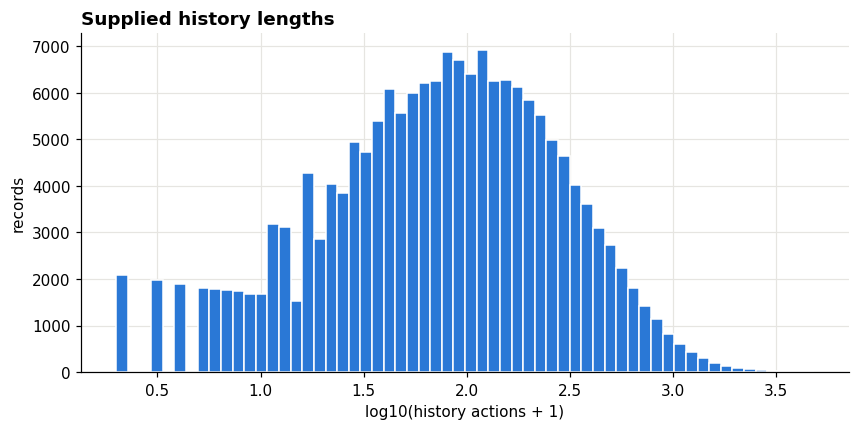

In [14]:
history_len = record_summary.history_len
hist_stats = history_len.describe(percentiles=[.05, .25, .5, .75, .95, .99]).rename("history actions per record")
display(save_table(hist_stats.to_frame(), "2_2_history_length", FULL_SCOPE))
display(save_table(full["action_mix"], "2_2_history_action_mix", FULL_SCOPE))
fig, ax = plt.subplots()
ax.hist(np.log10(history_len + 1), bins=60, color=BLUE, edgecolor="white")
ax.set(title="Supplied history lengths", xlabel="log10(history actions + 1)", ylabel="records")
save_fig(fig, "2_2_history_length")


In [15]:
display(save_table(full["popularity"], "2_2_item_popularity", FULL_SCOPE))
cold_stats = pd.DataFrame({"share": {"Distinct candidate IDs absent from all histories": full["cold_distinct_share"],
                                    "Candidate occurrences absent from all histories": full["cold_occurrence_share"]}})
display(save_table(cold_stats, "2_2_cold_item_coverage", FULL_SCOPE))
print("These are full-data descriptive history-absence measures, not coldness relative to a future training split.")


These are full-data descriptive history-absence measures, not coldness relative to a future training split.


,candidate exposures,history interactions,scope
distinct items,"8,362,535.0000","5,584,543.0000",full behaviour file / full catalog as applicable
mean per item,1.8547,4.7752,full behaviour file / full catalog as applicable
median per item,1.0000,1.0000,full behaviour file / full catalog as applicable
max per item,"1,135.0000","44,063.0000",full behaviour file / full catalog as applicable
share held by top 1%,0.1435,0.3487,full behaviour file / full catalog as applicable
share held by top 20%,0.5427,0.7669,full behaviour file / full catalog as applicable
share occurring once,0.7518,0.5592,full behaviour file / full catalog as applicable


,share,scope
Distinct candidate IDs absent from all histories,0.8054,full behaviour file / full catalog as applicable
Candidate occurrences absent from all histories,0.5654,full behaviour file / full catalog as applicable


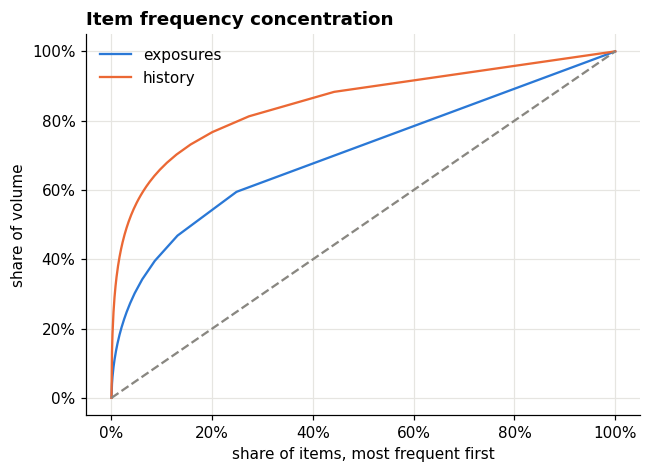

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for name, color in [("exposures", BLUE), ("history", ORANGE)]:
    x, y = full["lorenz"][name]
    ax.plot(x, y, color=color, label=name)
ax.plot([0, 1], [0, 1], color=MUTED, linestyle="--")
ax.set(title="Item frequency concentration", xlabel="share of items, most frequent first", ylabel="share of volume")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.legend(frameon=False)
save_fig(fig, "2_2_item_popularity")


### 4.6 Temporal patterns: time between actions

,between historical actions (raw units),last action to query (raw units),scope
count,"26,493,429.0000","173,831.0000",full behaviour file / full catalog as applicable
mean,"131,505.2417","466,656.8584",full behaviour file / full catalog as applicable
std,"711,888.8213","1,888,881.1996",full behaviour file / full catalog as applicable
min,0.0000,1.0000,full behaviour file / full catalog as applicable
25%,12.0000,69.0000,full behaviour file / full catalog as applicable
50%,67.0000,"19,287.0000",full behaviour file / full catalog as applicable
75%,"7,603.0000","184,469.0000",full behaviour file / full catalog as applicable
95%,"589,669.0000","2,233,784.5000",full behaviour file / full catalog as applicable
max,"48,911,483.0000","31,446,033.0000",full behaviour file / full catalog as applicable
share equal to zero,0.1059,0.0000,full behaviour file / full catalog as applicable


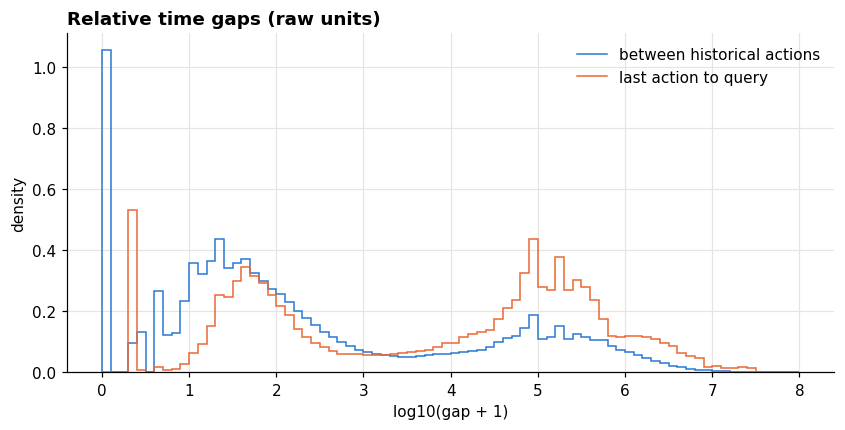

In [17]:
display(save_table(full["gap_table"], "2_2_time_gaps_raw", FULL_SCOPE))
fig, ax = plt.subplots()
bins, counts = full["gap_histogram"]
width = np.diff(bins)
ax.stairs(counts / counts.sum() / width, bins, color=BLUE, label="between historical actions")
since = record_summary.time_since_last_raw.to_numpy()
since_counts = np.histogram(np.log10(since + 1), bins=bins)[0]
ax.stairs(since_counts / since_counts.sum() / width, bins, color=ORANGE, label="last action to query")
ax.set(title="Relative time gaps (raw units)", xlabel="log10(gap + 1)", ylabel="density")
ax.legend(frameon=False)
save_fig(fig, "2_2_time_gaps_raw")


**Interpretation.** The intervals include short bursts and long gaps. This motivates testing recency-sensitive features, but does not establish that recent actions are more predictive. Initial zero placeholders are excluded from between-action summaries; genuine zero transition gaps remain. Calendar interpretations depend on the seconds assumption and the documented/raw-span discrepancy above.


### 4.7 Observed outcomes by broad category

Compare label shares by the candidate's L1 category. Differences are descriptive associations affected by exposure and query mix; they do not establish causal category effects or whether category depth improves within-query ranking. ID `-1` in this table denotes unavailable catalog metadata.


,impressions,engaged,purchased,engagement_rate,purchase_rate,scope
cate_id_1,,,,,,
920973,1505607,28964,1713,0.0192,0.0011,full behaviour file / full catalog as applicable
63959387,1252530,27447,1135,0.0219,0.0009,full behaviour file / full catalog as applicable
98371044,1098576,21423,2790,0.0195,0.0025,full behaviour file / full catalog as applicable
98719916,1071768,22163,855,0.0207,0.0008,full behaviour file / full catalog as applicable
68949654,953096,21284,780,0.0223,0.0008,full behaviour file / full catalog as applicable
24093831,814752,19011,663,0.0233,0.0008,full behaviour file / full catalog as applicable
56696958,634617,14057,1223,0.0222,0.0019,full behaviour file / full catalog as applicable
31606173,622682,13599,616,0.0218,0.0010,full behaviour file / full catalog as applicable
7098021,588027,10869,649,0.0185,0.0011,full behaviour file / full catalog as applicable


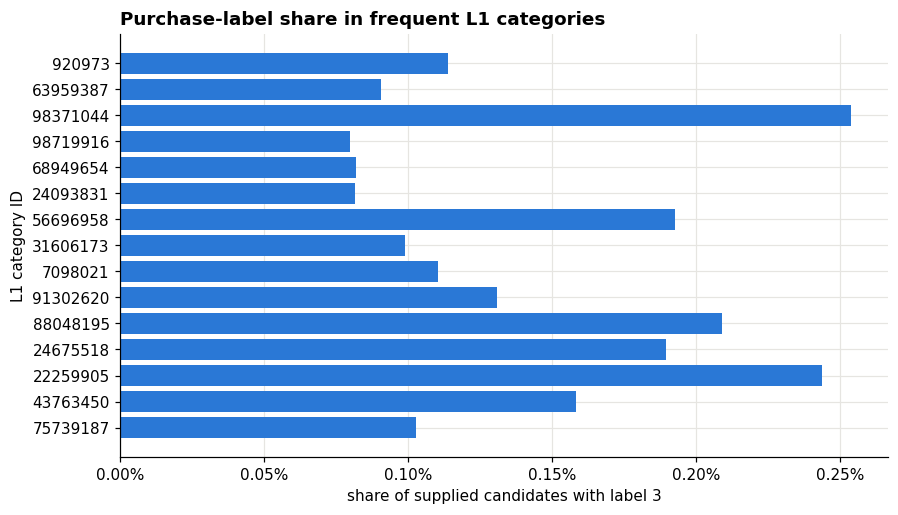

In [18]:
by_cate = full["category_rates"]
top_cate = by_cate.loc[by_cate.index != -1].head(15)
display(save_table(top_cate, "2_2_category_engagement", FULL_SCOPE))
fig, ax = plt.subplots(figsize=(9, 5))
plot = top_cate.iloc[::-1]
ax.barh(plot.index.astype(str), plot.purchase_rate, color=BLUE)
ax.set(title="Purchase-label share in frequent L1 categories", xlabel="share of supplied candidates with label 3", ylabel="L1 category ID")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1, decimals=2))
save_fig(fig, "2_2_category_engagement")


**Interpretation.** Graded labels let us distinguish recorded clicks, carts and purchases. Giving purchases greater ranking gain is an evaluation choice; it does not make the target direct purchase probability or monetary value. The controlled category-depth checks are in notebook 04.


## 5. Feature dictionary and descriptive statistics (report 2.3)

### 5.1 Raw fields

In [19]:
raw_dictionary = pd.DataFrame(
    [
        ("query", "user", "Current search query, anonymised term IDs", "text (separated term IDs)"),
        ("candidate_wid_list", "user", "Products shown for the query (the slate)", "list of item IDs"),
        ("candidate_label_list", "user", "Interaction per candidate: 0 none, 1 click, 2 cart, 3 purchase", "list of ordinal labels"),
        ("history_qry_list", "user", "Query behind each past action; -1 = not from search", "list of text / -1"),
        ("history_wid_list", "user", "Product of each past action", "list of item IDs"),
        ("history_type_list", "user", "Action type: CLICK, CART, FLW (follow), ORD (purchase)", "list of categorical"),
        ("history_time_list", "user", "Gap to previous action; final value = gap to current query", "list of nonnegative int gaps (raw unit; seconds assumed)"),
        ("wid", "product", "Product ID", "categorical ID"),
        ("name", "product", "Product title, anonymised term IDs", "text (separated term IDs)"),
        ("brand_id / brand_name", "product", "Brand", "categorical ID / text"),
        ("cate_id_1..4 / cate_name_1..4", "product", "Four-level category hierarchy", "categorical ID / text"),
        ("shop_id", "product", "Seller shop", "categorical ID"),
    ],
    columns=["field", "file", "description", "type / unit"],
).set_index("field")
display(save_table(raw_dictionary, "2_3_raw_fields", "released raw-field definitions"))

,file,description,type / unit,scope
field,,,,
query,user,"Current search query, anonymised term IDs",text (separated term IDs),released raw-field definitions
candidate_wid_list,user,Products shown for the query (the slate),list of item IDs,released raw-field definitions
candidate_label_list,user,"Interaction per candidate: 0 none, 1 click, 2 cart, 3 purchase",list of ordinal labels,released raw-field definitions
history_qry_list,user,Query behind each past action; -1 = not from search,list of text / -1,released raw-field definitions
history_wid_list,user,Product of each past action,list of item IDs,released raw-field definitions
history_type_list,user,"Action type: CLICK, CART, FLW (follow), ORD (purchase)",list of categorical,released raw-field definitions
history_time_list,user,Gap to previous action; final value = gap to current query,list of nonnegative int gaps (raw unit; seconds assumed),released raw-field definitions
wid,product,Product ID,categorical ID,released raw-field definitions
name,product,"Product title, anonymised term IDs",text (separated term IDs),released raw-field definitions


In [20]:
display(save_table(full["categorical"], "2_3_categorical_fields", FULL_SCOPE))


,distinct nonmissing,most common values,top value share among nonmissing,missing,scope
field,,,,,
brand_id,182585,"38645246, 54289642, 33241674",0.0428,0,full behaviour file / full catalog as applicable
shop_id,250934,"21749031, 54486560, 58139116",0.0013,103162,full behaviour file / full catalog as applicable
cate_id_1,76,"68949654, 24093831, 920973",0.0919,0,full behaviour file / full catalog as applicable
cate_id_2,671,"92351230, 18907346, 33276684",0.0373,0,full behaviour file / full catalog as applicable
cate_id_3,5819,"72526272, 10287851, 64184092",0.0127,0,full behaviour file / full catalog as applicable
cate_id_4,7137,"32130995, 462318, 23794926",0.0127,0,full behaviour file / full catalog as applicable
brand_name,171778,"35386929, 48193158417877054093144959865766, 26817499417877055225246659865766",0.0090,941660,full behaviour file / full catalog as applicable
history action,4,"ORD, CART, CLICK, FLW",0.4322,0,full behaviour file / full catalog as applicable
candidate label,4,"0, 1, 2, 3",0.9793,0,full behaviour file / full catalog as applicable


In [21]:
# Exact token/character length distributions cover each entire applicable file.
# Query-less -1 placeholders and empty metadata text are excluded and counted separately.
display(save_table(full["text_tokens"], "2_3_text_lengths_tokens", FULL_SCOPE))
display(save_table(full["text_chars"], "2_3_text_lengths_chars", FULL_SCOPE))


,count,min,max,mean,median,std,p25,p75,p95,empty / placeholder excluded,scope
past query (non-placeholder),"9,402,709.0000",1.0000,"1,441.0000",2.6827,2.0000,2.7472,1.0000,3.0000,5.0000,17264551,full behaviour file / full catalog as applicable
current query,"173,831.0000",1.0000,58.0000,2.7550,2.0000,1.8289,2.0000,3.0000,5.0000,0,full behaviour file / full catalog as applicable
product title,"12,141,247.0000",1.0000,78.0000,27.9133,27.0000,8.0565,23.0000,33.0000,42.0000,0,full behaviour file / full catalog as applicable
brand name (nonempty),"11,199,587.0000",1.0000,31.0000,2.5606,2.0000,1.7307,1.0000,4.0000,5.0000,941660,full behaviour file / full catalog as applicable
category L3 name,"12,141,247.0000",1.0000,15.0000,1.9134,2.0000,0.9377,1.0000,2.0000,4.0000,0,full behaviour file / full catalog as applicable


,count,min,max,mean,median,std,p25,p75,p95,scope
past query (non-placeholder),"9,402,709.0000",4.0000,"12,856.0000",22.7809,17.0000,24.3342,8.0000,26.0000,44.0000,full behaviour file / full catalog as applicable
current query,"173,831.0000",5.0000,517.0000,23.4561,17.0000,16.2440,16.0000,26.0000,44.0000,full behaviour file / full catalog as applicable
product title,"12,141,247.0000",5.0000,696.0000,247.4868,242.0000,71.9633,201.0000,293.0000,368.0000,full behaviour file / full catalog as applicable
brand name (nonempty),"11,199,587.0000",4.0000,278.0000,21.8767,17.0000,15.5210,8.0000,35.0000,44.0000,full behaviour file / full catalog as applicable
category L3 name,"12,141,247.0000",5.0000,134.0000,16.0298,17.0000,8.3927,8.0000,17.0000,34.0000,full behaviour file / full catalog as applicable


### 5.2 Sampled feature dictionary and statistics

Compute example features on the uniform 5,000-record sample. Historical inputs precede the test query. Candidate labels are used only for descriptive comparisons. Product/brand/shop and L1–L4 **path** counts use the validated definitions from notebook 04, split into all/search-associated/query-less sources. Missing candidate metadata produces unavailable features (`NaN`), not a match to other missing values.

Population history counts and cold flags have an `_eda` suffix: they use the full file here **for description only**. Future modelling must derive population features from training records only; supervised outcome encodings must be out-of-fold within training. A zero observed history count can also reflect missing historical metadata.


In [22]:
session_features, sample_pair = build_sample_features(DATA_DIR, sample_ids)
assert session_features.index.to_numpy().tolist() == sample_ids.tolist()
assert len(sample_pair) == record_summary.iloc[sample_ids].slate_len.sum()
assert sample_pair.label.gt(0).sum() == record_summary.iloc[sample_ids].positive_candidates.sum()
assert sample_pair.label.eq(3).sum() == record_summary.iloc[sample_ids].purchase_candidates.sum()
print(f"Sample records: {len(session_features):,}; full sampled candidate occurrences: {len(sample_pair):,}")
print("Category features match ancestor paths; no model architecture has been selected.")


Sample records: 5,000; full sampled candidate occurrences: 449,052
Category features match ancestor paths; no model architecture has been selected.


**Query features:** title shared-term count, query coverage and Jaccard similarity, plus any-term brand/category-name overlap. These compare complete `\x18`-separated IDs. Empty/unavailable names yield missing text features. An overlap with a brand name is lexical evidence; it does not establish a brand-intent query type. Current/history query overlap ignores token order; repeated historical queries can be multiple actions under one issued query.


In [23]:
query_columns = ["query_title_shared_terms", "query_title_coverage", "query_title_jaccard", "query_brand_match", "query_cate3_match"]
display(numeric_stats(sample_pair[query_columns].astype(float)))


,min,max,mean,median,std,missing,observed
query_title_shared_terms,0.0000,30.0000,1.8018,2.0000,1.2134,1960,447092
query_title_coverage,0.0000,1.0000,0.7210,1.0000,0.3395,1960,447092
query_title_jaccard,0.0000,1.0000,0.0768,0.0667,0.0580,1960,447092
query_brand_match,0.0000,1.0000,0.1941,0.0000,0.3955,25352,423700
query_cate3_match,0.0000,1.0000,0.3250,0.0000,0.4684,1960,447092


In [31]:
dictionary_rows = []
for feature in session_features.columns:
    description = {
        "hist_len": "Supplied past action count", "hist_share_no_query": "Fraction of supplied actions with query -1",
        "hist_metadata_coverage": "Fraction of historical actions whose product is in the catalog",
        "time_since_last_raw": "Final gap to test query, raw units", "time_since_last_h_assumed": "Final gap / 3600; seconds assumed",
        "history_span_days_assumed": "Historical transition gaps / 86400; seconds assumed",
        "query_len_chars": "Characters in current anonymised query", "query_len_terms": "Term occurrences in current query",
        "query_distinct_terms": "Distinct query term IDs", "slate_len": "Supplied candidates for the query",
        "history_query_max_jaccard": "Largest current/past query distinct-term Jaccard overlap",
        "history_query_any_overlap": "Any historical query shares a current-query term",
        "history_query_same_terms": "Any historical query has the same distinct term set",
    }.get(feature, "Historical action count by recorded type")
    unit = {
        "time_since_last_raw": "raw interval units (nonnegative integer)",
        "time_since_last_h_assumed": "hours (seconds assumed)",
        "history_span_days_assumed": "days (seconds assumed)",
        "query_len_chars": "characters",
    }.get(feature, "binary" if feature.endswith(("any_overlap", "same_terms")) else "ratio 0-1" if feature in ["hist_share_no_query", "hist_metadata_coverage", "history_query_max_jaccard"] else "count")
    dictionary_rows.append((feature, "search record", description, unit, "computed on 5,000 records"))
for feature in sample_pair.columns:
    if feature in ["session_id", "label"]:
        continue
    if feature.startswith("aff_"):
        description = "Prior action count for candidate's product/attribute/path in the named history source; NaN if candidate attribute unavailable"
        unit = "count"
    else:
        description = {
            "item_hist_popularity_eda": "Candidate action count in all histories; descriptive only, train-only in models",
            "item_cold_eda": "Candidate absent from all histories; descriptive, not training-split coldness",
            "item_in_catalogue": "Catalog contains candidate metadata", "item_seen_before": "Exact candidate ID occurs in own history",
            "item_ordered_before": "Own history contains ORD for this exact candidate",
            "query_title_shared_terms": "Number of shared distinct query/title term IDs",
            "query_title_coverage": "Shared distinct query/title terms divided by distinct query terms",
            "query_title_jaccard": "Shared distinct query/title terms divided by their union",
            "query_brand_match": "Any shared query/brand-name term; missing if name unavailable",
            "query_cate3_match": "Any shared query/L3-category-name term; missing if name unavailable",
        }[feature]
        unit = "count" if feature in ["item_hist_popularity_eda", "query_title_shared_terms"] else "ratio" if feature in ["query_title_coverage", "query_title_jaccard"] else "binary"
    dictionary_rows.append((feature, "candidate", description, unit, "computed on complete sampled slates"))
dictionary_rows.append(("recency/action weighting", "candidate/history", "Alternative weights to test after exploration; no fixed weights committed", "to decide", "planned, not computed"))
engineered_dictionary = pd.DataFrame(dictionary_rows, columns=["feature", "level", "description", "type/unit", "status"]).set_index("feature")
display(save_table(engineered_dictionary, "2_3_engineered_dictionary", SAMPLE_SCOPE))


,level,description,type/unit,status,scope
feature,,,,,
hist_len,search record,Supplied past action count,count,"computed on 5,000 records","5,000 complete records; seed 4222"
hist_share_no_query,search record,Fraction of supplied actions with query -1,ratio 0-1,"computed on 5,000 records","5,000 complete records; seed 4222"
hist_metadata_coverage,search record,Fraction of historical actions whose product is in the catalog,ratio 0-1,"computed on 5,000 records","5,000 complete records; seed 4222"
time_since_last_raw,search record,"Final gap to test query, raw units",raw interval units (nonnegative integer),"computed on 5,000 records","5,000 complete records; seed 4222"
time_since_last_h_assumed,search record,Final gap / 3600; seconds assumed,hours (seconds assumed),"computed on 5,000 records","5,000 complete records; seed 4222"
history_span_days_assumed,search record,Historical transition gaps / 86400; seconds assumed,days (seconds assumed),"computed on 5,000 records","5,000 complete records; seed 4222"
query_len_chars,search record,Characters in current anonymised query,characters,"computed on 5,000 records","5,000 complete records; seed 4222"
query_len_terms,search record,Term occurrences in current query,count,"computed on 5,000 records","5,000 complete records; seed 4222"
query_distinct_terms,search record,Distinct query term IDs,count,"computed on 5,000 records","5,000 complete records; seed 4222"


In [25]:
session_stats = numeric_stats(session_features.astype(float))
display(save_table(session_stats, "2_3_session_feature_stats", SAMPLE_SCOPE))


,min,max,mean,median,std,missing,observed,scope
hist_len,1.0000,"3,662.0000",151.7424,75.0000,230.9994,0,5000,"5,000 complete records; seed 4222"
hist_share_no_query,0.0000,1.0000,0.5980,0.6054,0.2012,0,5000,"5,000 complete records; seed 4222"
hist_metadata_coverage,0.0000,1.0000,0.9417,0.9624,0.0880,0,5000,"5,000 complete records; seed 4222"
time_since_last_raw,1.0000,"31,307,625.0000","506,387.5818","20,536.5000","2,027,787.2285",0,5000,"5,000 complete records; seed 4222"
time_since_last_h_assumed,0.0003,"8,696.5625",140.6632,5.7046,563.2742,0,5000,"5,000 complete records; seed 4222"
history_span_days_assumed,0.0000,364.8983,231.1434,278.6971,127.1200,0,5000,"5,000 complete records; seed 4222"
query_len_chars,6.0000,411.0000,23.5738,17.0000,16.9305,0,5000,"5,000 complete records; seed 4222"
query_len_terms,1.0000,46.0000,2.7684,2.0000,1.9048,0,5000,"5,000 complete records; seed 4222"
query_distinct_terms,1.0000,32.0000,2.7348,2.0000,1.6893,0,5000,"5,000 complete records; seed 4222"
slate_len,1.0000,200.0000,89.8104,90.0000,38.6726,0,5000,"5,000 complete records; seed 4222"


In [26]:
pair_columns = [c for c in sample_pair if c not in ["session_id", "label"]]
pair_stats = numeric_stats(sample_pair[pair_columns].astype(float))
engaged = sample_pair.label > 0
pair_stats["mean among engaged"] = sample_pair.loc[engaged, pair_columns].astype(float).mean()
pair_stats["mean among non-engaged"] = sample_pair.loc[~engaged, pair_columns].astype(float).mean()
pair_stats["ratio of feature means"] = pair_stats["mean among engaged"] / pair_stats["mean among non-engaged"]
display(save_table(pair_stats, "2_3_pair_feature_stats", SAMPLE_SCOPE))


,min,max,mean,median,std,missing,observed,mean among engaged,mean among non-engaged,ratio of feature means,scope
item_hist_popularity_eda,0.0000,"44,063.0000",33.5013,0.0000,345.9610,0,449052,228.4907,29.3663,7.7807,"5,000 complete records; seed 4222"
item_cold_eda,0.0000,1.0000,0.5685,1.0000,0.4953,0,449052,0.2770,0.5747,0.4820,"5,000 complete records; seed 4222"
item_in_catalogue,0.0000,1.0000,0.9956,1.0000,0.0659,0,449052,0.9971,0.9956,1.0015,"5,000 complete records; seed 4222"
item_seen_before,0.0000,1.0000,0.0079,0.0000,0.0885,0,449052,0.0982,0.0060,16.4176,"5,000 complete records; seed 4222"
item_ordered_before,0.0000,1.0000,0.0009,0.0000,0.0298,0,449052,0.0138,0.0006,22.4468,"5,000 complete records; seed 4222"
aff_all_product,0.0000,107.0000,0.0194,0.0000,0.4124,0,449052,0.2783,0.0139,20.0244,"5,000 complete records; seed 4222"
aff_all_brand,0.0000,444.0000,2.4657,0.0000,13.0855,1960,447092,3.5142,2.4435,1.4382,"5,000 complete records; seed 4222"
aff_all_shop,0.0000,316.0000,0.4873,0.0000,4.7055,5963,443089,1.5826,0.4640,3.4110,"5,000 complete records; seed 4222"
aff_all_L1,0.0000,"2,216.0000",26.7561,5.0000,78.0611,1960,447092,31.0619,26.6647,1.1649,"5,000 complete records; seed 4222"
aff_all_L2,0.0000,"2,084.0000",13.3025,1.0000,50.0903,1960,447092,17.3160,13.2172,1.3101,"5,000 complete records; seed 4222"


**Interpretation.** The ratio above compares feature means between engaged and non-engaged candidates. It is **not** an engagement-rate multiplier or proof of model improvement; pooled differences can reflect query mix, history length and exposure. Notebook 04 additionally checks within-search comparisons and tie-safe ranking.

The verified diagnostics show strong but rare exact-product evidence, broader shop/brand/category matches, a small extra gain at L4, and useful query-less history. They do not establish shop trust, causal preference or guaranteed improvements from adaptive history selection. The full-data population features shown here are not ready-to-use evaluation features.


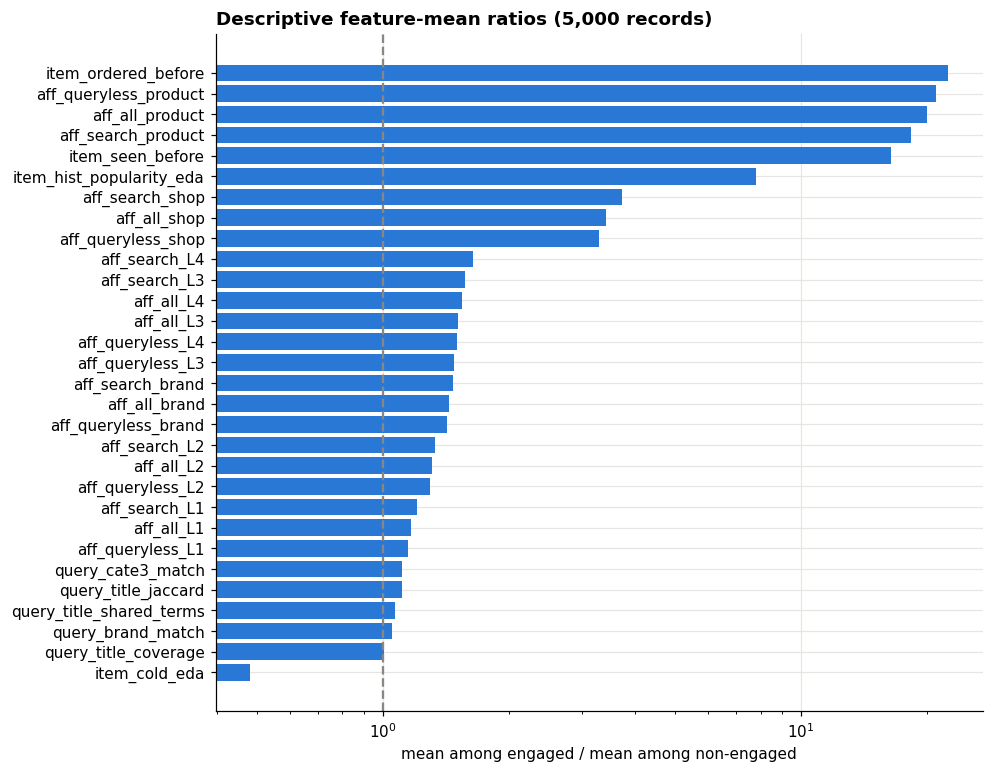

In [27]:
ratios = pair_stats["ratio of feature means"].replace([np.inf, -np.inf], np.nan).dropna()
ratios = ratios.loc[(ratios > 0) & ~ratios.index.isin(["item_in_catalogue"])]
fig, ax = plt.subplots(figsize=(9, 8))
ratios = ratios.sort_values()
ax.barh(ratios.index, ratios.values, color=BLUE)
ax.axvline(1, color=MUTED, linestyle="--")
ax.set_xscale("log")
ax.set(title="Descriptive feature-mean ratios (5,000 records)", xlabel="mean among engaged / mean among non-engaged")
save_fig(fig, "2_3_feature_mean_ratios")


## 5.3 Verified direction checks

Notebooks 03 and 04 contain the full diagnostic protocol and bootstrap intervals. Their tables below are loaded only when their seed, full-data record count and sampled candidate count match this run. Run those notebooks if the tables are absent; core raw exploration and feature statistics above are independent of them. Ranking heuristics are exploratory and do not select an architecture.


In [28]:
query_dir = TABLE_DIR / "query_validation"
history_dir = TABLE_DIR / "history_validation"
if (query_dir / "query_diagnostics_summary.json").is_file() and (history_dir / "history_match_summary.json").is_file():
    qsummary = json.loads((query_dir / "query_diagnostics_summary.json").read_text())
    hsummary = json.loads((history_dir / "history_match_summary.json").read_text())
    for summary in [qsummary, hsummary]:
        assert summary["seed"] == SEED and summary["sample_records"] == len(sample_ids)
        assert summary["total_records"] == n_sessions
    qrecords = pd.read_csv(query_dir / "query_diagnostics_per_search.csv")
    hrecords = pd.read_csv(history_dir / "history_match_per_search.csv")
    assert np.array_equal(qrecords.session_id, sample_ids) and np.array_equal(hrecords.session_id, sample_ids)
    assert qsummary["sample_candidate_occurrences"] == hsummary["candidate_occurrences"] == len(sample_pair)
    print(f"Full-data same-term repeats: {qsummary['full_data_distinct_token_set_repeat_records']:,} / {n_sessions:,}")
    print(f"Sample current/history term overlap: {qsummary['share_records_with_any_history_query_overlap']:.2%}")
    history_matches = pd.read_csv(history_dir / "history_match_coverage_and_engagement.csv")
    # Cross-check cached diagnostics against newly recomputed feature values.
    assert np.allclose(session_features.history_query_max_jaccard, qrecords.max_history_query_jaccard)
    assert np.array_equal(session_features.history_query_same_terms, qrecords.set_exact_repeat)
    for _, feature_row in history_matches.iterrows():
        feature_name = f"aff_{feature_row.source}_{feature_row.level}"
        assert int(sample_pair[feature_name].gt(0).sum()) == feature_row.matched_candidate_occurrences
    cols = ["level", "matched_share", "attribute_varies_search_share", "count_varies_search_share", "engagement_with_match", "engagement_without_match"]
    display(history_matches.loc[history_matches.source == "all", cols])
    display(pd.read_csv(history_dir / "history_match_depth_comparisons.csv"))
else:
    print("Detailed diagnostic tables absent. Run notebooks 03 and 04 to regenerate; no diagnostic claims loaded.")


Full-data same-term repeats: 610 / 173,831
Sample current/history term overlap: 41.14%


,level,matched_share,attribute_varies_search_share,count_varies_search_share,engagement_with_match,engagement_without_match
0,product,0.0079,0.9976,0.2952,0.2582,0.0189
1,brand,0.2269,0.8994,0.5944,0.0299,0.0181
2,shop,0.0716,0.9716,0.5078,0.0646,0.0175
3,L1,0.7517,0.6634,0.5896,0.0216,0.0183
4,L2,0.5749,0.7890,0.6070,0.0227,0.0182
5,L3,0.4066,0.8904,0.5596,0.0248,0.0181
6,L4,0.3759,0.9116,0.5592,0.0256,0.0179


,source,comparison,ndcg_difference,ci_low,ci_high
0,all,L2 minus L1,0.0033,0.0019,0.0047
1,all,L3 minus L2,0.0063,0.0045,0.0080
2,all,L4 minus L3,0.0013,0.0004,0.0022
3,search,L2 minus L1,0.0027,0.0014,0.0040
4,search,L3 minus L2,0.0041,0.0025,0.0057
5,search,L4 minus L3,0.0011,0.0003,0.0018
6,queryless,L2 minus L1,0.0034,0.0021,0.0047
7,queryless,L3 minus L2,0.0053,0.0037,0.0069
8,queryless,L4 minus L3,0.0013,0.0004,0.0021


## 6. Limitations and modelling implications

1. **File ordering encodes outcomes.** Positives precede negatives. Display-rank CTR is unavailable; exclude position features and use label-independent shuffling/random ties in future evaluation.
2. **Record grouping and collection period.** Each supplied row represents one user's last query according to the paper; no persistent ID or absolute row timestamps are released. The documented year is reportable, but cross-user temporal ordering is unavailable.
3. **Time interpretation.** Raw gaps and alignment are verified. Seconds-based hours/days are assumptions; some derived history spans exceed the documented year and need a unit/logging audit.
4. **Anonymised text and queries.** Boundaries are recoverable; meanings are not. Token overlap is lexical evidence, and repeated history-query entries may be actions from one search.
5. **Observed labels and selection.** Grade thresholds are not observed funnel transitions. The source test protocol excludes all-zero records; preserve/count them in EDA, and define treatment before model evaluation. Nearly all supplied searches have positives, so these labels do not establish general JD conversion rates.
6. **Missing metadata and sparse matches.** Lookup includes history and candidate products against the full catalog. Unknowns cannot match each other; missing historical metadata can conceal preferences. Full-data absence from history is different from training-split coldness.
7. **Category identity.** Some L3/L4 IDs have multiple parents. Features use ancestor paths consistently with notebook 04; finer matching can sacrifice coverage.
8. **Feature sampling and population statistics.** Raw summaries are full-data; feature statistics use 5,000 complete records. Model sample size/architecture remain open. Compute population features on training data only and supervised encodings out-of-fold.

The next modelling phase will compare a corrected previous-project baseline with controlled input/weighting changes. Exploratory count scores are not held-out model results and do not establish revenue gains.


In [29]:
print("Saved figures:")
for path in sorted(FIG_DIR.glob("*.png")):
    print(f"  {path.relative_to(REPORT_DIR)}")
print("Saved tables:")
for path in sorted(TABLE_DIR.glob("*.csv")):
    print(f"  {path.relative_to(REPORT_DIR)}")

Saved figures:
  figures\2_2_category_engagement.png
  figures\2_2_history_length.png
  figures\2_2_interaction_thresholds.png
  figures\2_2_item_popularity.png
  figures\2_2_position_artifact.png
  figures\2_2_slate_length.png
  figures\2_2_time_gaps_raw.png
  figures\2_3_feature_mean_ratios.png
Saved tables:
  tables\2_1_entity_counts.csv
  tables\2_1_history_span_days_assumed.csv
  tables\2_1_metadata_coverage_full.csv
  tables\2_1_sample_vs_full.csv
  tables\2_2_category_engagement.csv
  tables\2_2_cold_item_coverage.csv
  tables\2_2_feedback_semantics.csv
  tables\2_2_history_action_mix.csv
  tables\2_2_history_length.csv
  tables\2_2_interaction_labels.csv
  tables\2_2_interaction_thresholds.csv
  tables\2_2_item_popularity.csv
  tables\2_2_slate_length.csv
  tables\2_2_time_gaps_raw.csv
  tables\2_3_categorical_fields.csv
  tables\2_3_engineered_dictionary.csv
  tables\2_3_pair_feature_stats.csv
  tables\2_3_raw_fields.csv
  tables\2_3_session_feature_stats.csv
  tables\2_3_text